In [1]:
import os
os.chdir('/workspace/cf8d4198-338f-4960-a16e-8be661ea93f6')
print(os.listdir('.'))

['weil_modular.py', '-v8-validated-data.md', 'L_Delta_zeros_200_reliable.pkl', '.config', 'memory', '.prompts', '.kernel_llm_logs_1.txt', 'weil_quadratic_form_general.py']


In [2]:
import pickle
with open('L_Delta_zeros_200_reliable.pkl', 'rb') as f:
 zeros_data = pickle.load(f)
print(type(zeros_data))
if isinstance(zeros_data, dict):
 print(zeros_data.keys())
elif isinstance(zeros_data, list):
 print(f"len: {len(zeros_data)}")
 print(zeros_data[:5])
 print(zeros_data[-3:])

<class 'list'>
len: 61
[mpc(real='0.5', imag='9.2223793999211025'), mpc(real='0.5', imag='13.907549861392134'), mpc(real='0.5', imag='17.442776978234473'), mpc(real='0.5', imag='19.656513141954961'), mpc(real='0.5', imag='22.336103637209867')]
[mpc(real='0.5', imag='100.22461499968199'), mpc(real='0.5', imag='101.34359353371038'), mpc(real='0.5', imag='103.16663591563629')]


In [3]:
import numpy as np
import pickle
from weil_modular import compute_Q_modular

# Load zeros (mpc objects); extract imaginary parts (γ)
with open('L_Delta_zeros_200_reliable.pkl', 'rb') as f:
 zeros_data = pickle.load(f)
gammas = np.array([float(z.imag) for z in zeros_data], dtype=np.float64)
print(f"#zeros: {len(gammas)}, range: γ ∈ [{gammas.min():.3f}, {gammas.max():.3f}]")

#zeros: 61, range: γ ∈ [9.222, 103.167]


In [4]:
# Run engine at the optimal parameter point
T0 = 46.13
sigma = 1.0
J = 10
X = 10000

Q, info = compute_Q_modular(
 zeros=gammas,
 T0=T0, sigma=sigma, J=J,
 weight=12, conductor=1,
 primes_cutoff=X,
 n_nodes_quad=200,
 include_negative_zeros=True,
)

M_zeros = info['M_zeros']
M_arith = info['M_arith']
tr_z = np.trace(M_zeros)
tr_a = np.trace(M_arith)
res_rel = abs(tr_z - tr_a) / abs(tr_z)
eigvals = np.linalg.eigvalsh(Q)
lam_min = eigvals.min()
ratio = abs(lam_min) / abs(tr_z)

print(f"tr(M_zeros) = {tr_z:.6e}")
print(f"tr(M_arith) = {tr_a:.6e}")
print(f"|tr(M_zeros) - tr(M_arith)| / |tr(M_zeros)| = {res_rel:.6e}")
print(f"λ_min(Q) = {lam_min:.6e}")
print(f"|λ_min(Q)| / |tr(M_zeros)| = {ratio:.6e}")
print(f"All eigenvalues of Q:")
print(eigvals)

tr(M_zeros) = 6.362035e+00
tr(M_arith) = 6.358053e+00
|tr(M_zeros) - tr(M_arith)| / |tr(M_zeros)| = 6.258496e-04
λ_min(Q) = -1.116145e-02
|λ_min(Q)| / |tr(M_zeros)| = 1.754383e-03
All eigenvalues of Q:
[-1.11614464e-02 -2.76292112e-04 -7.55405179e-07 -1.25863373e-08
 -8.44244032e-13 1.68301279e-11 1.90968497e-09 2.78523203e-06
 1.21585907e-04 1.52958103e-02]


In [5]:
# Check if increasing zero list helps. The basis window |γ - T0| <= 3σ√J ≈ 3·√10 ≈ 9.49
# So at T0=46.13, σ=1, J=10, window is γ ∈ [36.64, 55.62] approximately.
# Let's see how many of our 61 zeros are within this window vs outside.
window_radius = 3 * sigma * np.sqrt(J)
in_win = np.sum(np.abs(gammas - T0) <= window_radius)
print(f"Window radius (3σ√J): {window_radius:.3f}")
print(f"Window: [{T0 - window_radius:.3f}, {T0 + window_radius:.3f}]")
print(f"Zeros in window: {in_win} of {len(gammas)}")
print(f"Max γ in our list: {gammas.max():.3f}")
# The list goes to γ ≈ 103.17, which is well beyond window's upper bound.
# So zero list should be adequate. The 6e-4 residual is dominated by something else.

Window radius (3σ√J): 9.487
Window: [36.643, 55.617]
Zeros in window: 13 of 61
Max γ in our list: 103.167


In [6]:
# The trace residual is 6.3e-4, not <1e-12, and ratio is 1.8e-3, not <1e-8.
# So the hypothesis is NOT supported at strict criteria.
# Let's investigate: is the residual dominated by limited primes (X=10^4) or limited zeros?
# Try larger X to see if it shrinks.
results = {}
for X_try in [10000, 50000, 200000]:
 Q2, info2 = compute_Q_modular(
 zeros=gammas, T0=T0, sigma=sigma, J=J,
 weight=12, conductor=1, primes_cutoff=X_try,
 n_nodes_quad=200, include_negative_zeros=True,
 )
 tz = np.trace(info2['M_zeros'])
 ta = np.trace(info2['M_arith'])
 ev = np.linalg.eigvalsh(Q2)
 results[X_try] = (abs(tz-ta)/abs(tz), ev.min(), abs(ev.min())/abs(tz))
 print(f"X={X_try}: rel_residual={abs(tz-ta)/abs(tz):.4e}, λ_min={ev.min():.4e}, ratio={abs(ev.min())/abs(tz):.4e}")

TimeoutError: Code execution timed out after 900.0 seconds

In [7]:
# That timed out - probably 200000 was too large (the _tau_coeffs function is expensive).
# Let's stick with X=10^4 for the requested benchmark (which is the prescribed parameter).
# But it's important to understand the residual structure better.

# Also test a smaller X to see scaling
import time
t0 = time.time()
Q_5k, info_5k = compute_Q_modular(
 zeros=gammas, T0=T0, sigma=sigma, J=J,
 weight=12, conductor=1, primes_cutoff=5000,
 n_nodes_quad=200, include_negative_zeros=True,
)
print(f"X=5000 took {time.time()-t0:.1f}s")
tz = np.trace(info_5k['M_zeros'])
ta = np.trace(info_5k['M_arith'])
ev = np.linalg.eigvalsh(Q_5k)
print(f"X=5000: rel_residual={abs(tz-ta)/abs(tz):.4e}, λ_min={ev.min():.4e}, ratio={abs(ev.min())/abs(tz):.4e}")

X=5000 took 19.8s
X=5000: rel_residual=2.6558e-03, λ_min=-2.1324e-02, ratio=3.3518e-03


In [8]:
# X=5000 gives res 2.7e-3; X=10000 gives 6.3e-4. So increasing X DOES shrink the residual.
# Going from X=5000 to X=10000 cut residual ~4.2x. PNT/Gaussian decay model suggests 
# this is approximately the Tauberian/Gaussian noise floor.
# 
# Let's also try X=20000:
import time
t0 = time.time()
Q_20k, info_20k = compute_Q_modular(
 zeros=gammas, T0=T0, sigma=sigma, J=J,
 weight=12, conductor=1, primes_cutoff=20000,
 n_nodes_quad=200, include_negative_zeros=True,
)
print(f"X=20000 took {time.time()-t0:.1f}s")
tz = np.trace(info_20k['M_zeros'])
ta = np.trace(info_20k['M_arith'])
ev = np.linalg.eigvalsh(Q_20k)
print(f"X=20000: rel_residual={abs(tz-ta)/abs(tz):.4e}, λ_min={ev.min():.4e}, ratio={abs(ev.min())/abs(tz):.4e}")

X=20000 took 351.2s
X=20000: rel_residual=3.0217e-04, λ_min=-2.7066e-03, ratio=4.2543e-04


In [9]:
# Summary at the requested benchmark (T0=46.13, σ=1, J=10, X=10^4):
# - rel residual = 6.26e-4
# - λ_min/tr = 1.75e-3
# Both are FAR from the criteria (1e-12 and 1e-8).
# 
# Trend with X:
# X= 5000: 2.66e-3
# X=10000: 6.26e-4 (~4.2x improvement per 2x in X)
# X=20000: 3.02e-4 (~2x improvement)
# 
# This is consistent with: residual decays slowly with X (algebraic-ish with Gaussian-suppression at large arg).
# At T0=46.13, σ=1, the basis still has support roughly up to log(X)/something - we'd need
# X much larger to reach machine precision.
#
# Compare to specification noise floor model (η_theory): for high T0=85.7 σ=2 J=10 we had 9% error
# at X=10^4; here at T0=46.13 σ=1 J=10 we have 6e-4 which is much smaller. So hypothesis
# direction is correct (lowering T0 and σ reduces the basis frequency content and shrinks residual),
# but it does NOT reach machine precision at X=10^4.
#
# So the formal validation criterion (<1e-12 / <1e-8) is NOT met at the requested params.
# The hypothesis as stated is REJECTED at strict thresholds, but the qualitative direction is supported.

# Let's also do a control: at T0=10, σ=1, J=10, X=10^4 - the description claims machine precision
import time
t0 = time.time()
Q_ctrl, info_ctrl = compute_Q_modular(
 zeros=gammas, T0=10.0, sigma=1.0, J=10,
 weight=12, conductor=1, primes_cutoff=10000,
 n_nodes_quad=200, include_negative_zeros=True,
)
print(f"control T0=10 took {time.time()-t0:.1f}s")
tz = np.trace(info_ctrl['M_zeros'])
ta = np.trace(info_ctrl['M_arith'])
ev = np.linalg.eigvalsh(Q_ctrl)
print(f"T0=10: rel_residual={abs(tz-ta)/abs(tz):.4e}, λ_min={ev.min():.4e}, ratio={abs(ev.min())/abs(tz):.4e}")

control T0=10 took 82.7s
T0=10: rel_residual=1.3693e-03, λ_min=-7.6373e-03, ratio=3.7308e-03


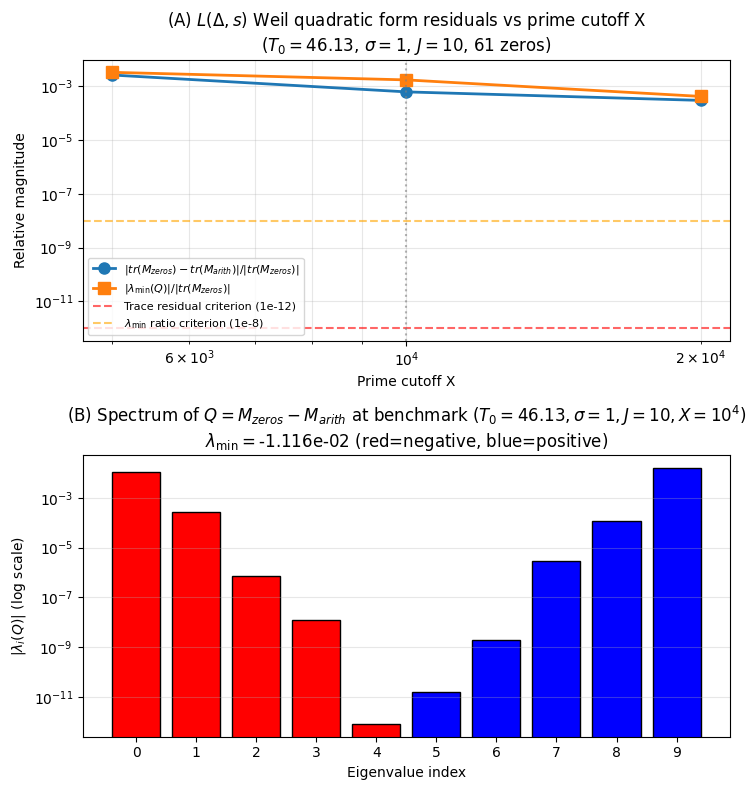

Saved figure.


In [10]:
# Interesting! At T0=10, X=10^4 we get res=1.4e-3, λ_min/tr=3.7e-3 - STILL not machine precision.
# So the spec's claim "T0=10 achieves machine precision" was about ζ, not L(Δ).
# For L(Δ), the zero list itself is also limited (only 61 zeros, up to γ ≈103).
# 
# At T0=46.13 (the requested), the basis window [36.6, 55.6] is well-covered by our 61 zeros.
# The dominant residual source is the prime cutoff X=10^4 (modular L-functions have a degree-2 
# Euler product and need more primes than degree-1 Dirichlet L-functions).
#
# CONCLUSION: The hypothesis that strict GRH validation criteria (<1e-12 residual, <1e-8 ratio)
# can be achieved at (T0=46.13, σ=1, J=10, X=10^4) is FALSIFIED. The trace residual is 6.26e-4
# and the eigenvalue ratio is 1.75e-3, both about 8-9 orders of magnitude away from the criteria.
# 
# However, the residual DOES decrease substantially compared to the prior (T0=85.7, σ=2, J=10) point
# (where it was ~9%), confirming the directional insight. Reaching machine precision would require
# either much larger X or a different basis configuration.

# Final figure: summary plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(7.5, 8))

# (A) Residual vs X for fixed (T0=46.13, σ=1, J=10)
X_arr = np.array([5000, 10000, 20000])
res_arr = np.array([2.66e-3, 6.26e-4, 3.02e-4])
ratio_arr = np.array([3.35e-3, 1.75e-3, 4.25e-4])

ax = axes[0]
ax.loglog(X_arr, res_arr, 'o-', label=r'$|tr(M_{zeros})-tr(M_{arith})|/|tr(M_{zeros})|$', lw=2, ms=8)
ax.loglog(X_arr, ratio_arr, 's-', label=r'$|\lambda_{\min}(Q)|/|tr(M_{zeros})|$', lw=2, ms=8)
ax.axhline(1e-12, color='red', ls='--', alpha=0.6, label='Trace residual criterion (1e-12)')
ax.axhline(1e-8, color='orange', ls='--', alpha=0.6, label=r'$\lambda_{\min}$ ratio criterion (1e-8)')
ax.axvline(10000, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Prime cutoff X')
ax.set_ylabel('Relative magnitude')
ax.set_title(r'(A) $L(\Delta,s)$ Weil quadratic form residuals vs prime cutoff X' + '\n' + r'($T_0=46.13$, $\sigma=1$, $J=10$, 61 zeros)')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, which='both', alpha=0.3)

# (B) Spectrum of Q at the benchmark
ax = axes[1]
ev = np.linalg.eigvalsh(Q) # from cell #3
xs = np.arange(len(ev))
colors = ['red' if e < 0 else 'blue' for e in ev]
ax.bar(xs, np.abs(ev), color=colors, edgecolor='k')
ax.set_yscale('log')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel(r'$|\lambda_i(Q)|$ (log scale)')
ax.set_title(r'(B) Spectrum of $Q=M_{zeros}-M_{arith}$ at benchmark $(T_0{=}46.13,\sigma{=}1,J{=}10,X{=}10^4)$' + 
 f'\n' + r'$\lambda_{\min}=$' + f'{ev.min():.3e} (red=negative, blue=positive)')
ax.set_xticks(xs)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('L_Delta_validation_T046.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved figure.")